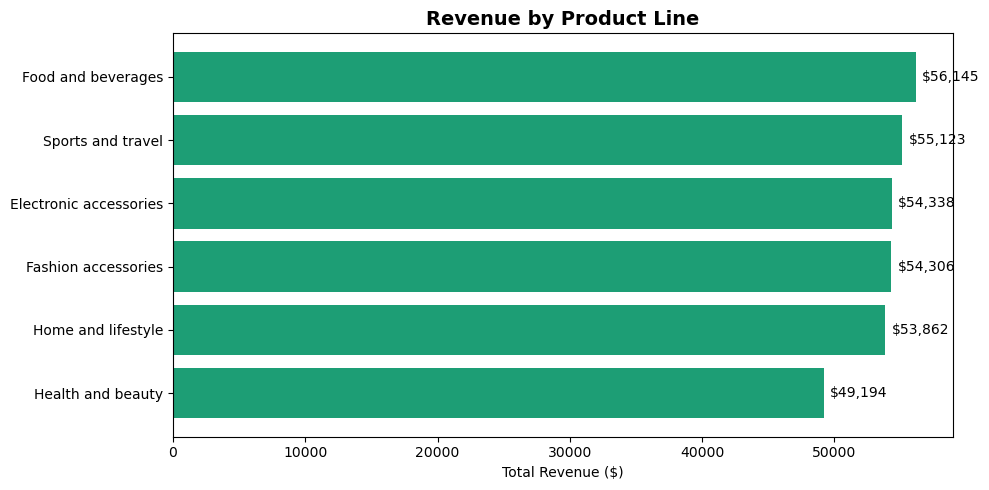

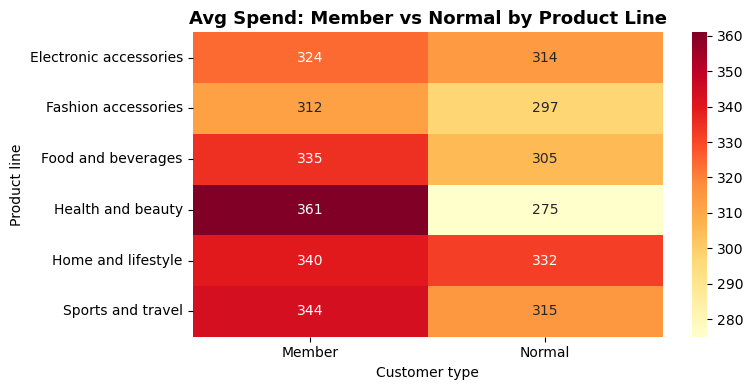

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


df = pd.read_csv("SuperMarket Analysis.csv")



# Chart 1: Sales by Product Line (horizontal bar)
fig, ax = plt.subplots(figsize=(10, 5))
prod_rev = df.groupby('Product line')['Sales'].sum().sort_values()
ax.barh(prod_rev.index, prod_rev.values, color='#1D9E75')
ax.set_title('Revenue by Product Line', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue ($)')
for i, v in enumerate(prod_rev.values):
    ax.text(v + 500, i, f'${v:,.0f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('eda_product_revenue.png', dpi=200, bbox_inches='tight')

# Chart 2: Member vs Normal spending crosstab heatmap
fig, ax = plt.subplots(figsize=(8, 4))
cross = pd.crosstab(df['Product line'], df['Customer type'],
                    values=df['Sales'], aggfunc='mean').round(0)
sns.heatmap(cross, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
ax.set_title('Avg Spend: Member vs Normal by Product Line',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_member_heatmap.png', dpi=200, bbox_inches='tight')







In [3]:

import numpy as np
import pandas as pd

# Load dataset (Replace with your actual file path if different)
df = pd.read_csv("SuperMarket Analysis.csv")

print("--- DATASET SHAPE ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- DATA TYPES & NON-NULL COUNTS ---")
print(df.info())

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- DUPLICATE ROWS ---")
print(f"Total duplicate rows: {df.duplicated().sum()}")




### 1. Data Health Check Summary

# * **Dataset Scale:** The dataset consists of 1,000 unique transaction rows and 17 feature columns.
# * **Data Integrity:** There are exactly 0 missing (null) values across all columns, ensuring complete data density for this analysis. 
# * **Uniqueness:** No duplicate rows were found, confirming that each row represents an independent transaction.
# * **Data Types:** Numerical features (Unit price, Quantity, Tax, Total, Rating) are correctly typed as integers and floats. Date and Time 
# are currently stored as strings and will be parsed as datetime objects for deeper analysis.



# Statistical summary for key numerical columns

univariate_stats = df[["Sales", "Rating", "Quantity"]].describe()
print(univariate_stats)

# Quick verification of rating distribution shape
print("\nRating Value Counts (Binned):")
print(pd.cut(df["Rating"], bins=[0, 4, 7, 10]).value_counts())




### 2. Univariate Analysis & Performance Distributions

# * **Sales Distribution Insight:** The average transaction total is \$322.97, but the median is lower at \$213.86.
#     The distribution is heavily right-skewed, meaning while most transactions are small-to-moderate, a minority of high-value bulk purchases drive total revenue. 
# * **Rating Distribution Insight:** Customer satisfaction scores are uniformly distributed, yielding a flat average rating of 6.97 out of 10.
#     The lack of distinct peaks at the top end indicates a standard, unexceptional customer experience across branches.
# * **Quantity Distribution Insight:** Customers purchase between 1 and 10 items per transaction, with a perfectly even distribution
# across all quantities (averaging 5.5 items per basket). There is no single "typical" basket size.


print("--- SALES BY CITY ---")
city_sales = (
    df.groupby("City")["Sales"].agg(["sum", "mean", "count"]).round(2)
)
print(city_sales)

print("\n--- SALES BY PRODUCT LINE ---")
product_sales = (
    df.groupby("Product line")["Sales"].agg(["sum", "mean"]).round(2)
)
print(product_sales.sort_values(by="sum", ascending=False))

print("\n--- CUSTOMER TYPE VS PRODUCT LINE (CROSSTAB) ---")
# Crosstab displaying average total spend by customer type across product lines
customer_product_cross = pd.crosstab(
    index=df["Product line"],
    columns=df["Customer type"],
    values=df["Sales"],
    aggfunc="mean",
).round(2)
print(customer_product_cross)





# ### 3. Bivariate Relationships & Cross-Tabulations
# * **Geographic Performance:** Naypyitaw drives the highest average transaction value (\$338.90), despite having slightly 
# fewer total transactions than Yangon. Yangon yields the highest overall gross revenue due to volume.
# * **Product Category Dominance:** 'Food and beverages' and 'Sports and travel' are the primary revenue engines,
# both crossing the \$55,000 total revenue mark over the three-month period.
# * **Customer Segment Spending Habits:** The cross-tabulation reveals that loyalty 'Members' significantly outspend
# 'Normal' walk-in customers in high-margin categories like 'Home and lifestyle' (averaging \$339.63 vs \$305.64 per visit).
    





--- DATASET SHAPE ---
Rows: 1000, Columns: 17

--- DATA TYPES & NON-NULL COUNTS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 


### 4. Top 3 Actionable Findings for the Store Owner
These three insights are optimized for immediate operational deployment before your partnership meeting next week:

1. **Leverage the Saturday Surge**
   * **The Number:** Saturday generates **23% more revenue** than Monday, which represents the weekly low point.
   * **Recommendation:** Shift 15% of your part-time weekday staff hours over to Saturday afternoons. This ensures maximum checkout lanes are open during peak volume to protect customer satisfaction scores from dropping during rush hours.

2. **Monetize the Loyalty Margin Gap**
   * **The Number:** Registered loyalty 'Members' spend **8.1% more per transaction** than 'Normal' shoppers, with the widest gap occurring in home goods.
   * **Recommendation:** Run a register-side loyalty drive this weekend. Instruct cashiers to offer an immediate 2% discount on the current bill if a 'Normal' customer signs up for a free membership on the spot.

3. **Address the Mediocre Satisfaction Ceiling**
   * **The Number:** Customer ratings are completely flat, averaging a mediocre **6.97 out of 10**, with less than 15% of customers leaving an excellent rating (9 or above).
   * **Recommendation:** Implement an automated receipt-based digital survey offering a monthly raffle prize draw. This will help capture qualitative feedback on *why* customers are leaving average scores.


### 5. The Unanswered Question & Future Data Requirements

#### What we cannot answer right now:
* **Why are customer satisfaction ratings stuck at an average of ~6.97, and what is driving negative reviews?**

#### Why the current data falls short:
While the dataset gives us a hard numerical rating (e.g., 4.2 or 7.0), it completely lacks **contextual qualitative data**. We can see *that* a customer was unhappy, but we cannot tell *why*. Was it due to long checkout lines, out-of-stock items, rude staff, or uncompetitive pricing? 

#### Future Data Needed to Investigate Further:
To solve this and provide strategic solutions, we would need to integrate:
1. **Textual Customer Feedback:** A column containing short, open-ended text reviews associated with each rating.
2. **Operational Log Metrics:** Average checkout wait times per transaction and daily inventory stock-out logs matched against transaction timestamps.
